In [3]:
# CUSTOMER CHURN PREDICTION - Full ML Pipeline

# Imports & Settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [4]:
# Load Dataset

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Basic Info & Null Check

print('--- Data Types ---')
print(df.dtypes)
print('\n--- Null Values ---')
print(df.isnull().sum())

# Data Cleaning

# Fix TotalCharges — spaces stored as missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop customerID — not useful as a feature
df.drop(columns=['customerID'], inplace=True)

# Encode target column to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Cleaned shape: {df.shape}')
print(f'\nChurn distribution:\n{df["Churn"].value_counts()}')

--- Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Null Values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperl

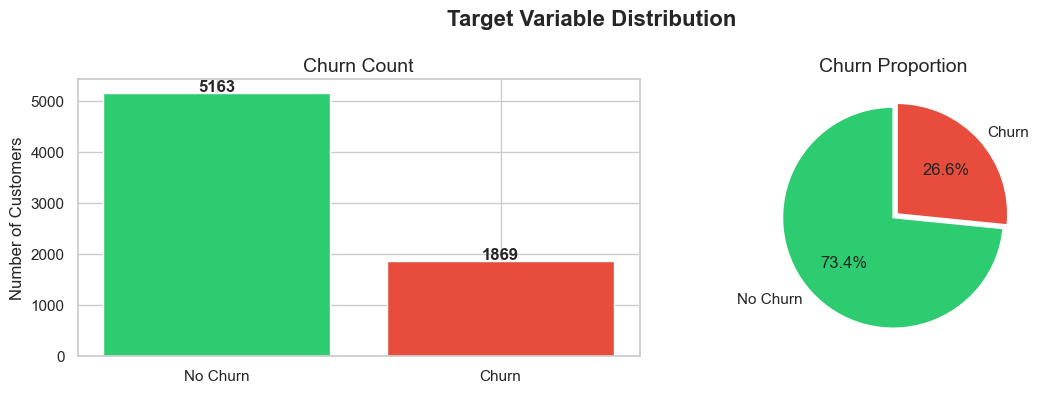

Insight: Dataset is imbalanced (~26% churn). We will handle this with SMOTE.


In [6]:
# EDA: Churn Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Churn'].value_counts()
axes[0].bar(['No Churn', 'Churn'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Count', fontsize=14)
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Proportion', fontsize=14)

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Dataset is imbalanced (~26% churn). We will handle this with SMOTE.')

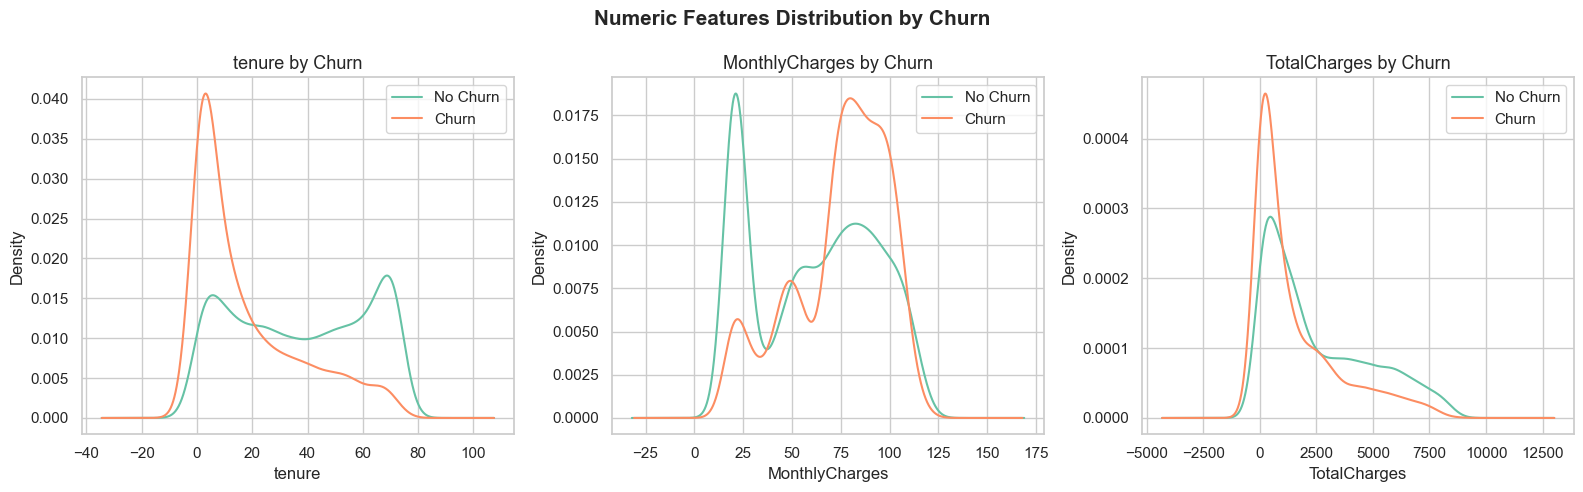

Insight: Short tenure & high monthly charges are strongly linked to churn.


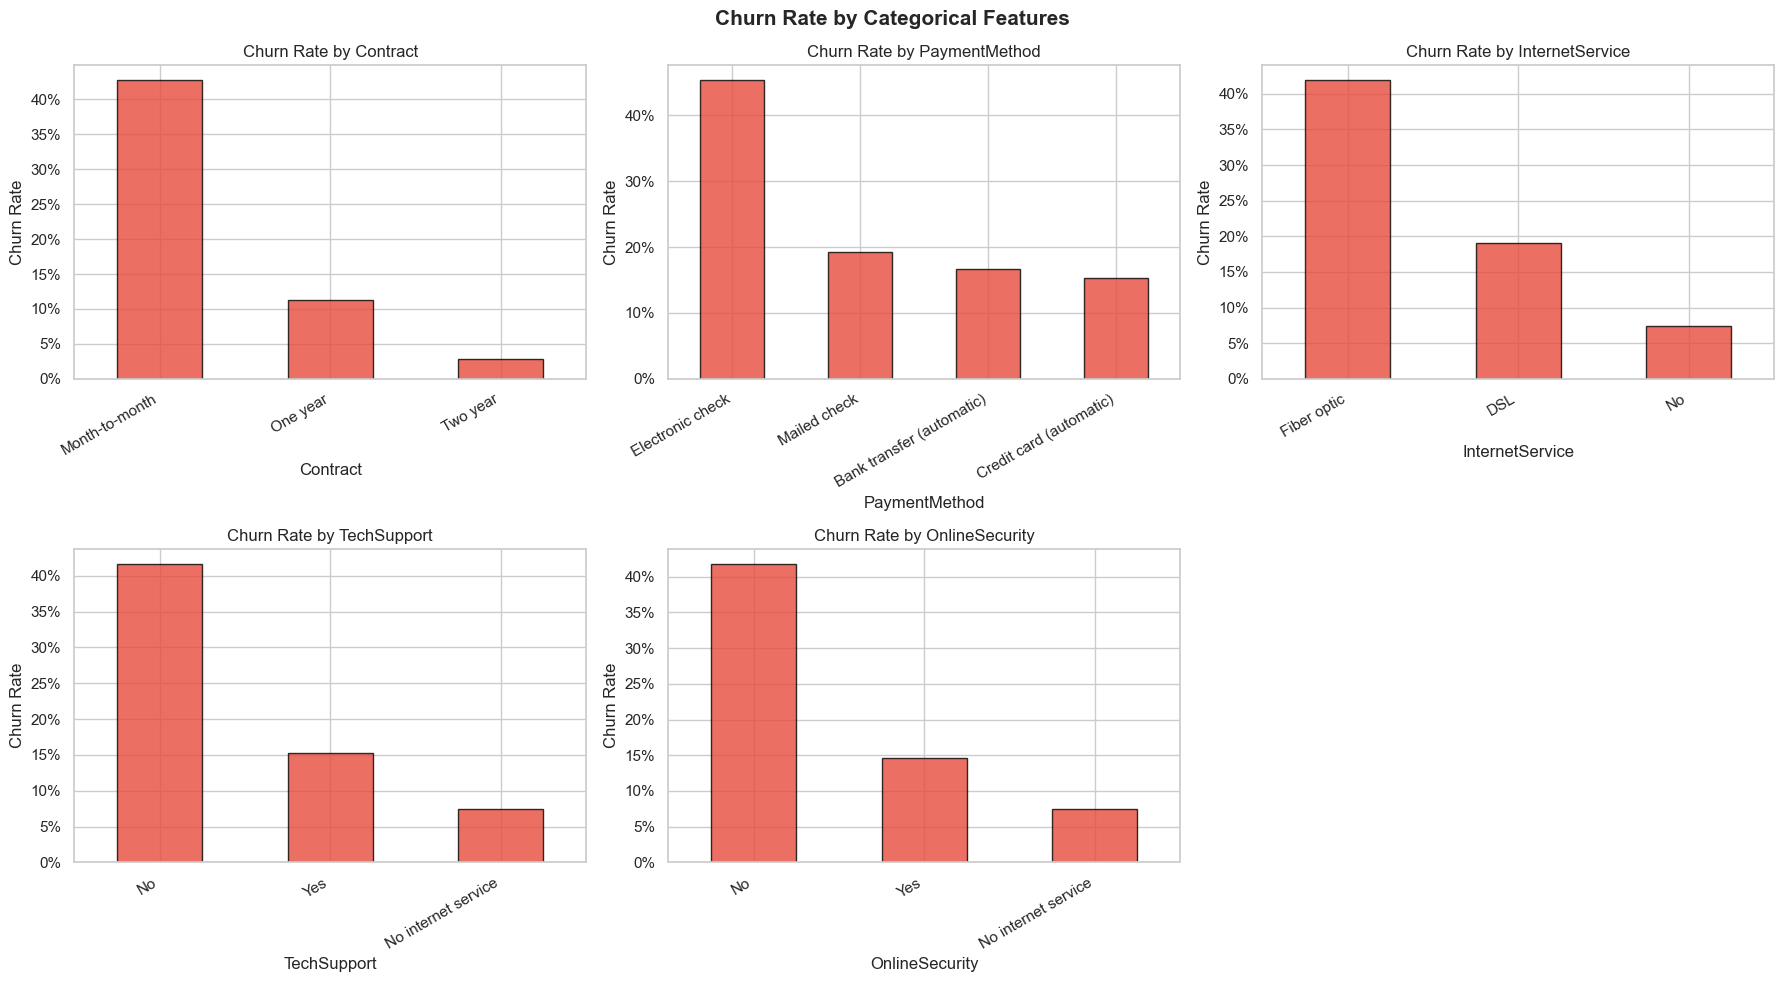

 Insight: Month-to-month contracts & electronic check payment have the highest churn.


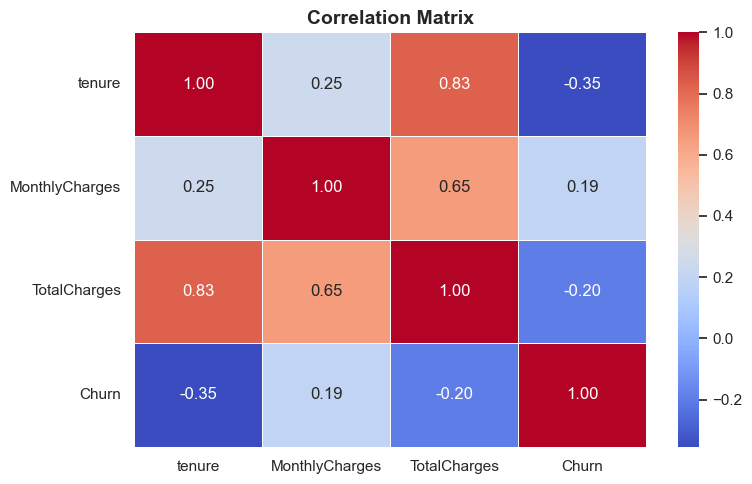

In [7]:
# EDA: Numeric Features vs Churn

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    df.groupby('Churn')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(f'{col} by Churn', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].legend(['No Churn', 'Churn'])

plt.suptitle('Numeric Features Distribution by Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Short tenure & high monthly charges are strongly linked to churn.')

# EDA: Categorical Features Churn Rate

cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#e74c3c', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Insight: Month-to-month contracts & electronic check payment have the highest churn.')


# EDA: Correlation Heatmap

plt.figure(figsize=(8, 5))
corr = df[numeric_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Feature Engineering & Preprocessing

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

df_model = df.copy()

# New feature: average monthly spend
df_model['AvgMonthlySpend'] = df_model['TotalCharges'] / (df_model['tenure'] + 1)

# New feature: tenure bucket
df_model['TenureBucket'] = pd.cut(
    df_model['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4+yr']
)

# Label encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'TenureBucket']
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# One-hot encode multi-class categoricals
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

print(f'Feature engineered shape: {df_model.shape}')
df_model.head(2)

#  Train/Test Split + SMOTE
y = df_model['Churn']
X = df_model.drop(columns=['Churn'])

# Scale numeric features
scaler = StandardScaler()
num_feats = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
X[num_feats] = scaler.fit_transform(X[num_feats])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance with SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'Train size: {X_train_res.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Resampled churn balance: {pd.Series(y_train_res).value_counts().to_dict()}')

Feature engineered shape: (7032, 33)
Train size: 8260 | Test size: 1407
Resampled churn balance: {0: 4130, 1: 4130}


Logistic Regression: ROC-AUC = 0.8148
Random Forest: ROC-AUC = 0.8139
Gradient Boosting: ROC-AUC = 0.8281
XGBoost: ROC-AUC = 0.7998

 Best model: Gradient Boosting (AUC = 0.8281)


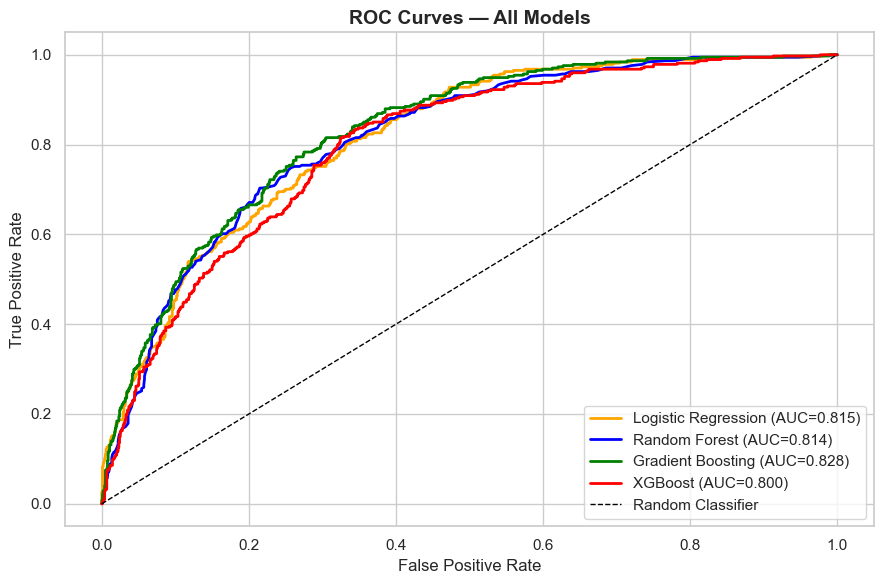

In [14]:
# Train All Models

# Install XG Boost
!pip install xgboost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, roc_curve, ConfusionMatrixDisplay)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba, 'auc': auc}
    print(f'{name}: ROC-AUC = {auc:.4f}')

best_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n Best model: {best_name} (AUC = {results[best_name]["auc"]:.4f})')

# ROC Curves

plt.figure(figsize=(9, 6))
colors = ['orange', 'blue', 'green', 'red']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

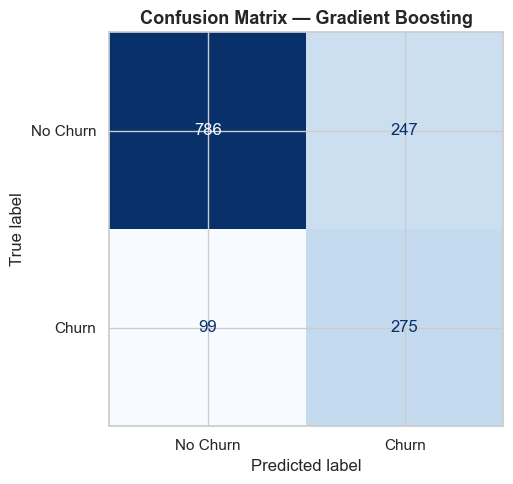


--- Classification Report: Gradient Boosting ---
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1033
       Churn       0.53      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407



In [16]:
# Confusion Matrix & Classification Report

best_model = results[best_name]
cm = confusion_matrix(y_test, best_model['y_pred'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n--- Classification Report: {best_name} ---')
print(classification_report(y_test, best_model['y_pred'], target_names=['No Churn', 'Churn']))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 3.6 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


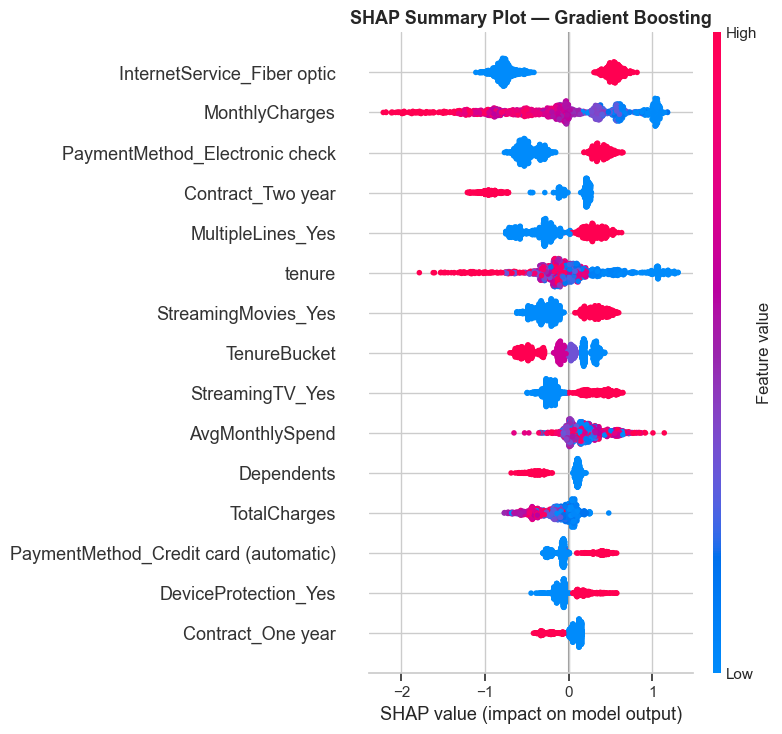

Red = high feature value pushes toward churn. Blue = low value.


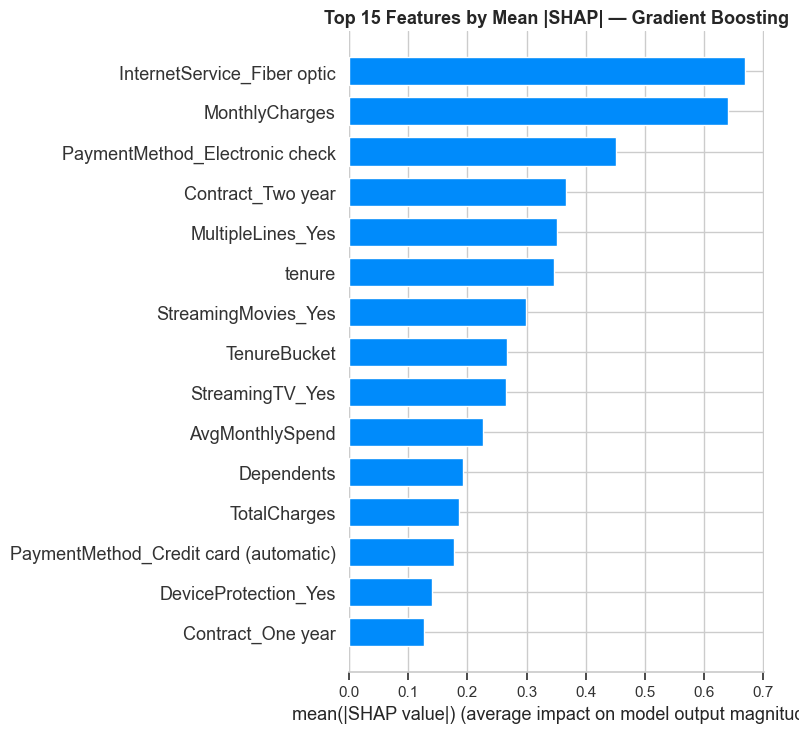

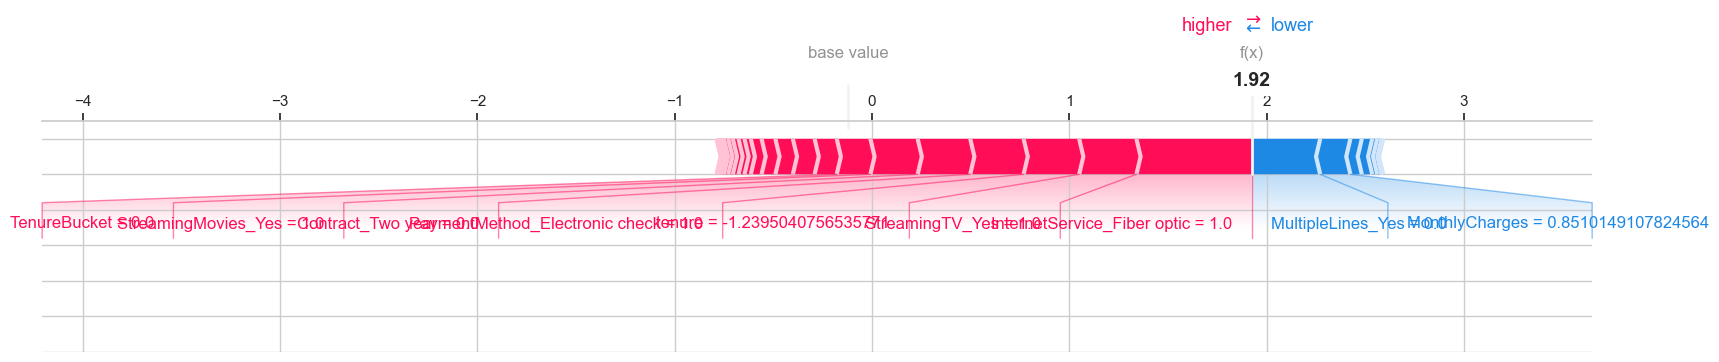

Churn probability for this customer: 87.25%


In [20]:
#  SHAP: Global Feature Importance (Beeswarm)
!pip install shap
import shap

best_clf = results[best_name]['model']
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test)

# For binary classification pick class 1 (Churn)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(sv, X_test, plot_type='dot', show=False, max_display=15)
plt.title(f'SHAP Summary Plot — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Red = high feature value pushes toward churn. Blue = low value.')

# SHAP: Bar Chart (Mean |SHAP|)
plt.figure()
shap.summary_plot(sv, X_test, plot_type='bar', show=False, max_display=15)
plt.title(f'Top 15 Features by Mean |SHAP| — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP: Local Explanation (Single High-Risk Customer)

high_risk_idx = np.where(results[best_name]['y_proba'] > 0.85)[0]
sample_idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

shap.initjs()
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list)
    else explainer.expected_value,
    sv[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=True
)

print(f'Churn probability for this customer: {results[best_name]["y_proba"][sample_idx]:.2%}')